In [6]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

In [7]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [5]:
x_train.shape


(60000, 28, 28)

In [8]:
x_test.shape

(10000, 28, 28)

In [10]:
import matplotlib.pyplot as plt

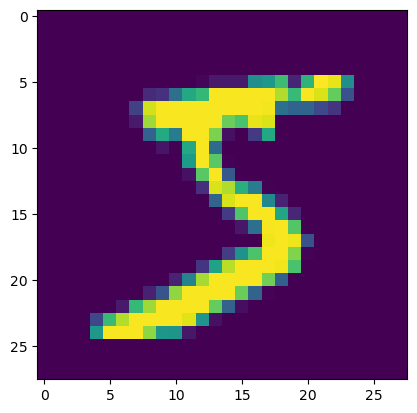

In [11]:
plt.imshow(x_train[0])

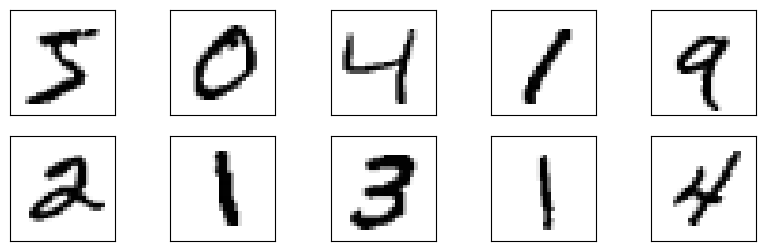

In [12]:
plt.figure(figsize=(10,3))
for i in range(10):
  plt.subplot(2, 5, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(x_train[i], cmap=plt.cm.binary)
plt.show()

In [13]:
# Data Preprocessing - Normalize images
x_train = x_train / 255.0
x_test = x_test / 255.0

In [14]:
model = Sequential([
    # Input Layer - 784 neurons in input layer
    Flatten(input_shape=(28, 28)),
    # Hidden Layer(s)
    Dense(512, activation="sigmoid"),
    Dense(256, activation="sigmoid"),
    Dense(128, activation="sigmoid"),
    # Output Layer
    Dense(10, activation="softmax")
    # Dense(1, activation="sigmoid")
])

C:\Users\aggar\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         401,920 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model.compile(optimizer="adam",
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=["accuracy"])

In [17]:
model.fit(x_train, y_train,
          validation_data=(x_test, y_test),
          epochs=5)

Epoch 1/5


C:\Users\aggar\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1214: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8902 - loss: 0.3712 - val_accuracy: 0.9481 - val_loss: 0.1699
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9580 - loss: 0.1385 - val_accuracy: 0.9611 - val_loss: 0.1299
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9713 - loss: 0.0922 - val_accuracy: 0.9633 - val_loss: 0.1151
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9793 - loss: 0.0667 - val_accuracy: 0.9739 - val_loss: 0.0834
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9845 - loss: 0.0488 - val_accuracy: 0.9767 - val_loss: 0.0749


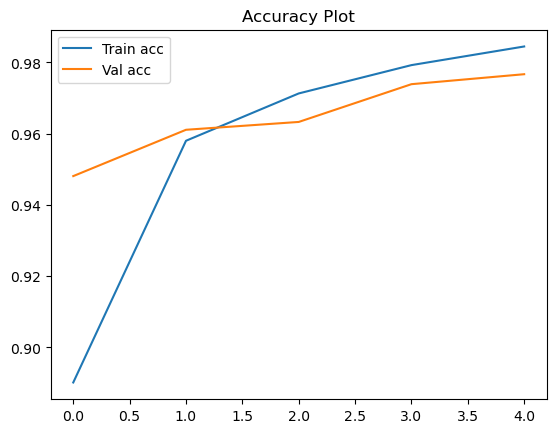

In [18]:
plt.plot(model.history.history["accuracy"], label="Train acc")
plt.plot(model.history.history["val_accuracy"], label="Val acc")
plt.legend()
plt.title("Accuracy Plot")
plt.show()

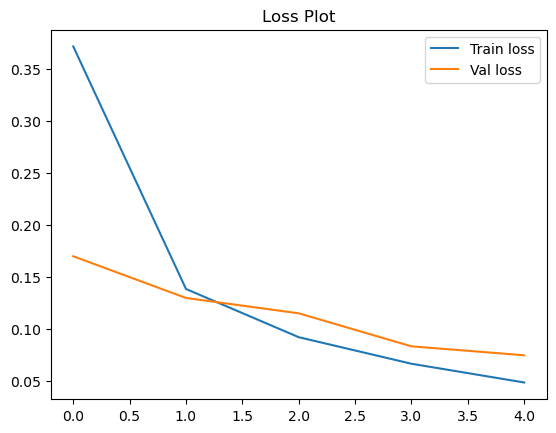

In [19]:
plt.plot(model.history.history["loss"], label="Train loss")
plt.plot(model.history.history["val_loss"], label="Val loss")
plt.legend()
plt.title("Loss Plot")
plt.show()